# Shape Analysis

Phân tích độ lệch (Skewness) và độ nhọn (Kurtosis) của phân phối dữ liệu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Load cleaned data
df = pd.read_csv('data/youtube_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']

print(f"Dataset shape: {df.shape}")
print(f"Analyzing {len(numerical_cols)} numerical variables")

Dataset shape: (17586, 15)
Analyzing 10 numerical variables


In [3]:
# Phân tích hình dạng phân phối (Shape Analysis)

shape_analysis = pd.DataFrame({
    'Variable': numerical_cols,
    'Skewness': [df[col].skew() for col in numerical_cols],
    'Kurtosis': [df[col].kurtosis() for col in numerical_cols]
})

# Thêm cột phân loại
def classify_skewness(skew):
    if skew > 1:
        return 'Highly Right Skewed'
    elif skew > 0.5:
        return 'Moderately Right Skewed'
    elif skew > -0.5:
        return 'Approximately Symmetric'
    elif skew > -1:
        return 'Moderately Left Skewed'
    else:
        return 'Highly Left Skewed'

def classify_kurtosis(kurt):
    if kurt > 3:
        return 'Leptokurtic (Heavy Tails)'
    elif kurt < -3:
        return 'Platykurtic (Light Tails)'
    else:
        return 'Mesokurtic (Normal)'

shape_analysis['Skewness Type'] = shape_analysis['Skewness'].apply(classify_skewness)
shape_analysis['Kurtosis Type'] = shape_analysis['Kurtosis'].apply(classify_kurtosis)

shape_analysis.round(2)

,Variable,Skewness,Kurtosis,Skewness Type,Kurtosis Type
0,duration,16.99,603.88,Highly Right Skewed,Leptokurtic (Heavy Tails)
1,bitrate,2.41,8.76,Highly Right Skewed,Leptokurtic (Heavy Tails)
2,bitrate(video),2.46,9.22,Highly Right Skewed,Leptokurtic (Heavy Tails)
3,height,1.12,0.47,Highly Right Skewed,Mesokurtic (Normal)
4,width,1.30,2.31,Highly Right Skewed,Mesokurtic (Normal)
5,frame rate,-1.36,2.87,Highly Left Skewed,Mesokurtic (Normal)
6,frame rate(est.),0.75,-1.36,Moderately Right Skewed,Mesokurtic (Normal)
7,views,97.61,10653.82,Highly Right Skewed,Leptokurtic (Heavy Tails)
8,likes,75.60,6439.71,Highly Right Skewed,Leptokurtic (Heavy Tails)
9,comments,49.28,3119.21,Highly Right Skewed,Leptokurtic (Heavy Tails)


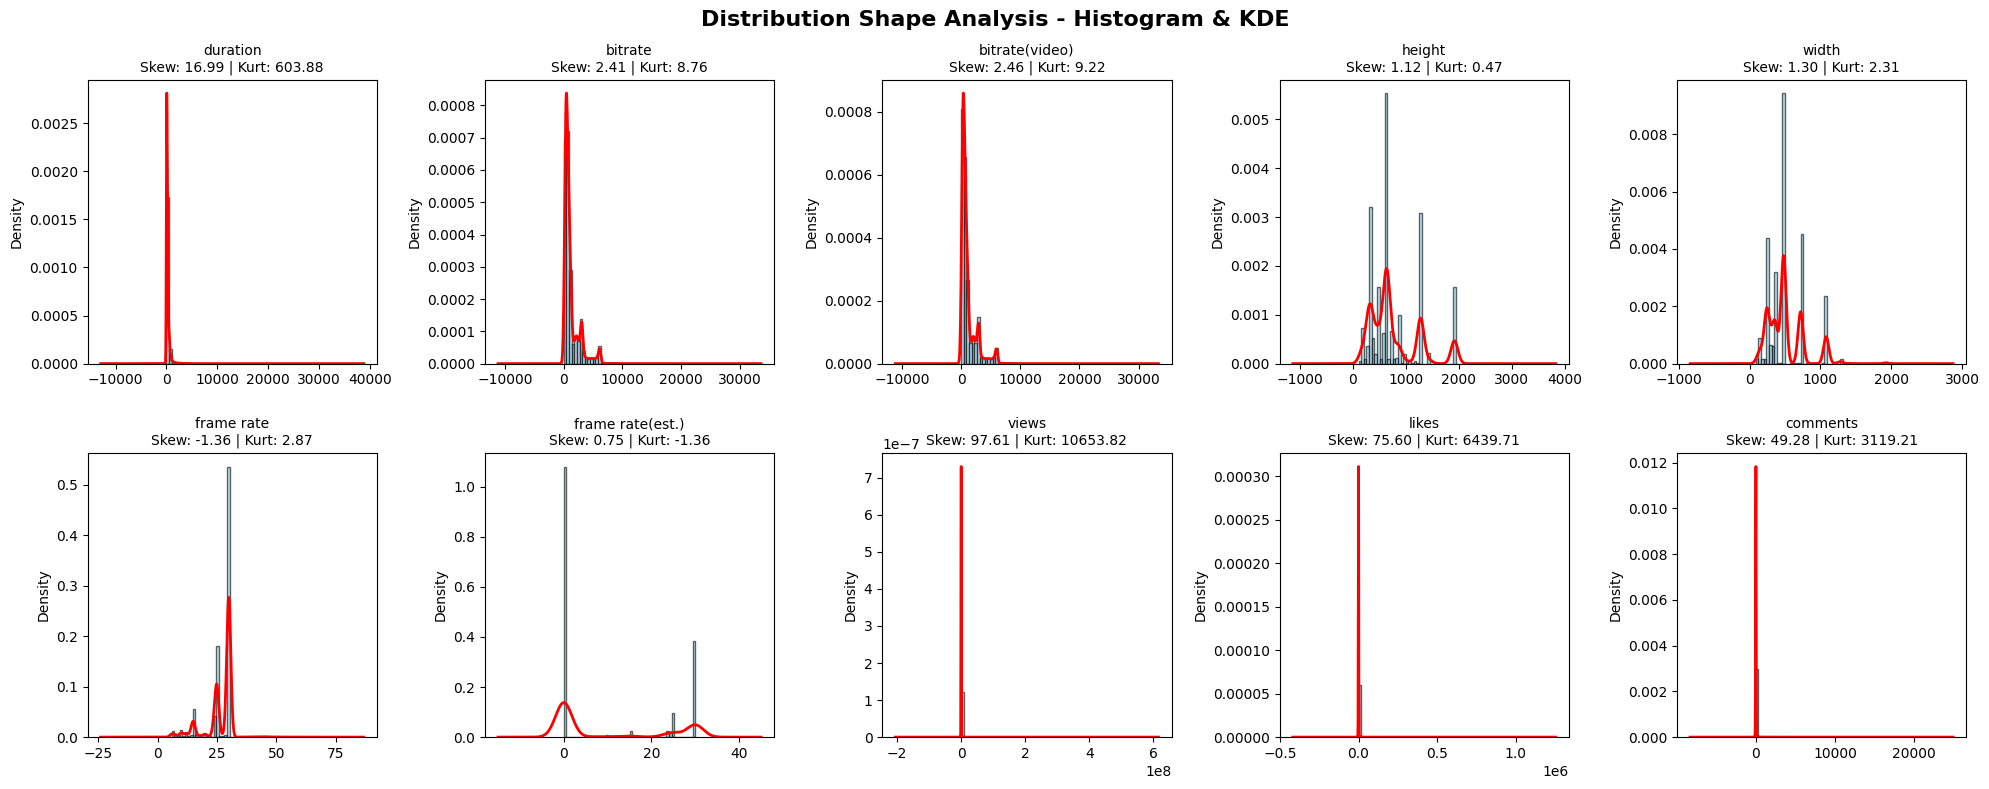

In [4]:
# Visualize Shape Analysis
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Distribution Shape Analysis - Histogram & KDE', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    row = idx // 5
    col_idx = idx % 5
    
    ax = axes[row, col_idx]
    
    # Histogram + KDE
    ax.hist(df[col], bins=50, alpha=0.6, color='skyblue', edgecolor='black', density=True)
    df[col].plot(kind='kde', ax=ax, color='red', linewidth=2)
    
    # Thêm thông tin skewness và kurtosis
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    ax.set_title(f'{col}\nSkew: {skew:.2f} | Kurt: {kurt:.2f}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

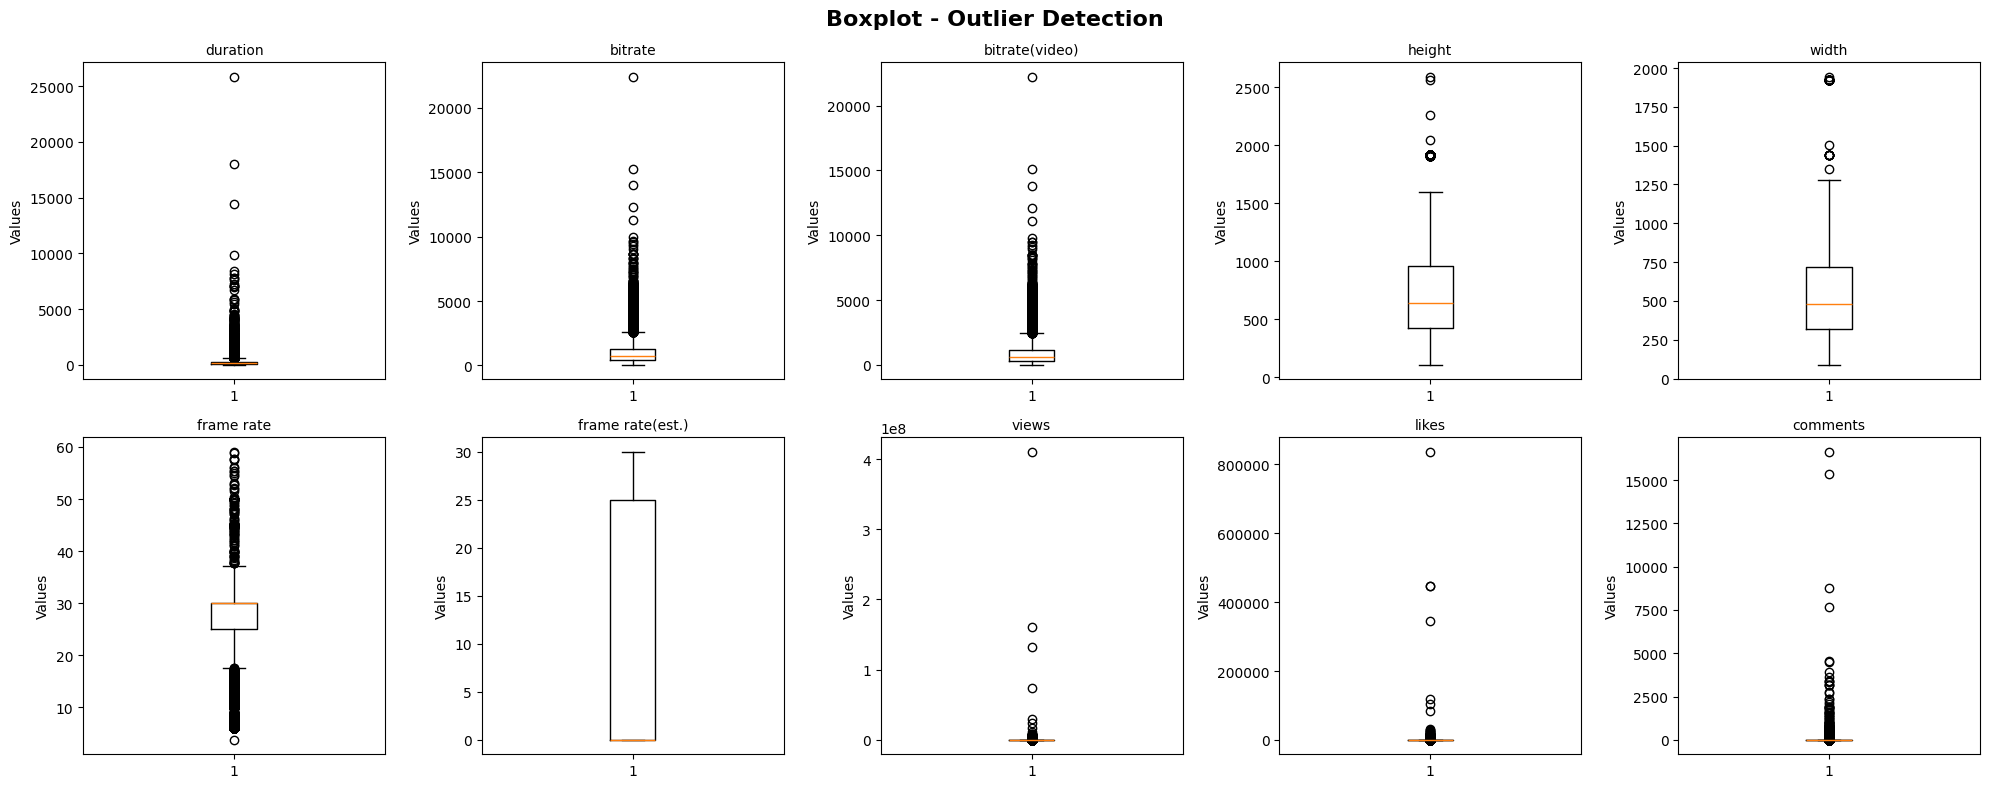

In [5]:
# Boxplot để xem outliers
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Boxplot - Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    row = idx // 5
    col_idx = idx % 5
    
    ax = axes[row, col_idx]
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Values')

plt.tight_layout()
plt.show()

- Hầu hết có phân phối **right-skewed** (views, likes, comments có skewness rất cao)
- Có nhiều **outliers** đặc biệt ở views, likes, comments
- Cần xử lý outliers trong phần Distribution Analysis tiếp theo